<a href="https://colab.research.google.com/github/ValeriaZav26/Jobs_market_analysis/blob/main/data_jobs_market_analysis_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import os

# Авторизация в API Kaggle с помощью персонального токена
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_a250c22332c177c45b751f6dc4979724'

# Проверяем доступность API, выведя список активных соревнований
!kaggle competitions list

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection             2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3          

In [29]:
import kagglehub
# Автоматически скачиваем актуальную версию нужного датасета с Glassdoor через kagglehub
path = kagglehub.dataset_download("rashikrahmanpritom/data-science-job-posting-on-glassdoor")

# Выводим локальный путь на сервере Google Colab, куда сохранились файлы
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'data-science-job-posting-on-glassdoor' dataset.
Path to dataset files: /kaggle/input/data-science-job-posting-on-glassdoor


In [30]:

# Выводим список всех файлов в скачанной директории, чтобы узнать точное имя CSV-файла
print(os.listdir(path))

['Uncleaned_DS_jobs.csv', 'Cleaned_DS_Jobs.csv']


In [31]:
# Импортируем основные библиотеки для анализа данных и визуализации
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Указываем имя целевого файла с «сырыми» данными
file_name = 'Uncleaned_DS_jobs.csv'

# Формируем полный корректный путь к файлу с учетом операционной системы
full_path = os.path.join(path, file_name)

# Загружаем данные из CSV-файла в датафрейм Pandas
df = pd.read_csv(full_path)

# Выводим первые 5 строк таблицы
df.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna"
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1
2,2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


In [32]:
# Посмотрим на общую структуру данных, типы столбцов и количество записей
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              672 non-null    int64  
 1   Job Title          672 non-null    object 
 2   Salary Estimate    672 non-null    object 
 3   Job Description    672 non-null    object 
 4   Rating             672 non-null    float64
 5   Company Name       672 non-null    object 
 6   Location           672 non-null    object 
 7   Headquarters       672 non-null    object 
 8   Size               672 non-null    object 
 9   Founded            672 non-null    int64  
 10  Type of ownership  672 non-null    object 
 11  Industry           672 non-null    object 
 12  Sector             672 non-null    object 
 13  Revenue            672 non-null    object 
 14  Competitors        672 non-null    object 
dtypes: float64(1), int64(2), object(12)
memory usage: 78.9+ KB


In [33]:
# Создаем копию датасета, чтобы случайно не испортить исходные данные
df_clean = df.copy()

In [34]:
# ОЧИСТКА КОЛОНКИ С ЗАПЛАТОЙ
# Убираем строки, где зарплата вообще не указана (если вместо нее стоит текст '-1')
df_clean = df_clean[df_clean['Salary Estimate'] != '-1']

# Удаляем текст "(Glassdoor est.)", знаки "$" и букву "K"
df_clean['salary_parsed'] = df_clean['Salary Estimate'].apply(lambda x: x.split('(')[0])
df_clean['salary_parsed'] = df_clean['salary_parsed'].str.replace('$', '').str.replace('K','')

# Разделяем строку по дефису на минимальную и максимальную зарплату
df_clean['min_salary'] = df_clean['salary_parsed'].apply(lambda x: int(x.split('-')[0]))
df_clean['max_salary'] = df_clean['salary_parsed'].apply(lambda x: int(x.split('-')[1]))

# Считаем среднюю зарплату
df_clean['avg_salary'] = (df_clean['max_salary'] + df_clean['min_salary']) / 2

# Удаляем промежуточный технический столбец

df_clean.drop(columns=['salary_parsed'], inplace=True)


In [35]:
#ОЧИСТКА НАЗВАНИЙ КОМПАНИЙ (Company Name)

# Если рейтинг компании больше 0, убираем из названия последние 4 символа (\n3.1)
# Используем lambda-функцию: если рейтинг > 0, отрезаем текст до знака переноса строки '\n'
df_clean['Company Name'] = df_clean.apply(lambda x: x['Company Name'].split('\n')[0] if x['Rating'] > 0 else x['Company Name'], axis=1)


# Заменяем '-1' на официальный np.nan (пустоту)
df_clean = df_clean.replace('-1', np.nan)
df_clean = df_clean.replace(-1, np.nan)

# Проверяем процент пропусков в колонке "Competitors" (Конкуренты)
missing_competitors = df_clean['Competitors'].isna().mean() * 100
print(f'Процент пропусков в колонке Competitors: {missing_competitors} %')

# Так как пропусков больше 70%, удаляем эту колонку — она бесполезна для анализа
df_clean = df_clean.drop(columns=['Competitors'])

# Пропуски в важной колонке 'Rating' заполняем медианным значением рейтинга по всему датасету
median_rating = df_clean['Rating'].median()
df_clean['Rating'] = df_clean['Rating'].fillna(median_rating)



Процент пропусков в колонке Competitors: 74.55357142857143 %


In [36]:
# 2.4. СОЗДАНИЕ ПРИЗНАКОВ ИЗ ТЕКСТА

# Переводим всё описание вакансии в нижний регистр, чтобы поиск не зависел от больших букв
df_clean['Job Description'] = df_clean['Job Description'].str.lower()

# Создаем новые колонки-флаги (1 — навык нужен, 0 — навык не упомянут)
df_clean['python_job'] = df_clean['Job Description'].apply(lambda x: 1 if 'python' in x else 0)
df_clean['sql_job'] = df_clean['Job Description'].apply(lambda x: 1 if 'sql' in x else 0)
df_clean['excel_job'] = df_clean['Job Description'].apply(lambda x: 1 if 'excel' in x else 0)
df_clean['tableau_job'] = df_clean['Job Description'].apply(lambda x: 1 if 'tableau' in x else 0)
df_clean['spark_job'] = df_clean['Job Description'].apply(lambda x: 1 if 'spark' in x else 0)

df_clean.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,Sector,Revenue,min_salary,max_salary,avg_salary,python_job,sql_job,excel_job,tableau_job,spark_job
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),description\n\nthe senior data scientist is re...,3.1,Healthfirst,"New York, NY","New York, NY",1001 to 5000 employees,1993.0,...,Insurance,Unknown / Non-Applicable,137,171,154.0,0,0,0,0,0
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"secure our nation, ignite your future\n\njoin ...",4.2,ManTech,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968.0,...,Business Services,$1 to $2 billion (USD),137,171,154.0,0,1,0,0,0
2,2,Data Scientist,$137K-$171K (Glassdoor est.),overview\n\n\nanalysis group is one of the lar...,3.8,Analysis Group,"Boston, MA","Boston, MA",1001 to 5000 employees,1981.0,...,Business Services,$100 to $500 million (USD),137,171,154.0,1,0,1,0,0
3,3,Data Scientist,$137K-$171K (Glassdoor est.),job description:\n\ndo you have a passion for ...,3.5,INFICON,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000.0,...,Manufacturing,$100 to $500 million (USD),137,171,154.0,1,1,1,0,0
4,4,Data Scientist,$137K-$171K (Glassdoor est.),data scientist\naffinity solutions / marketing...,2.9,Affinity Solutions,"New York, NY","New York, NY",51 to 200 employees,1998.0,...,Business Services,Unknown / Non-Applicable,137,171,154.0,1,1,1,0,0


In [37]:
# 2.4. СОЗДАНИЕ ПРИЗНАКОВ ИЗ ТЕКСТА

# Переводим всё описание вакансии в нижний регистр, чтобы поиск не зависел от больших букв
df_clean['Job Description'] = df_clean['Job Description'].str.lower()

# Создаем новые колонки-флаги (1 — навык нужен, 0 — навык не упомянут)
df_clean['python_job'] = df_clean['Job Description'].apply(lambda x: 1 if 'python' in x else 0)
df_clean['sql_job'] = df_clean['Job Description'].apply(lambda x: 1 if 'sql' in x else 0)
df_clean['excel_job'] = df_clean['Job Description'].apply(lambda x: 1 if 'excel' in x else 0)
df_clean['tableau_job'] = df_clean['Job Description'].apply(lambda x: 1 if 'tableau' in x else 0)
df_clean['spark_job'] = df_clean['Job Description'].apply(lambda x: 1 if 'spark' in x else 0)


In [38]:

#Анализ востребованности навыков и их влияния на зарплату
skills = ['python_job', 'sql_job', 'excel_job', 'tableau_job', 'spark_job']
skill_analysis = []

for skill in skills:
    # Считаем долю вакансий с этим мнемоником
    demand_pct = df_clean[skill].mean() * 100
    # Считаем среднюю зарплату для вакансий С этим навыком
    avg_sal = df_clean[df_clean[skill] == 1]['avg_salary'].mean()
    skill_analysis.append({'Навык': skill.replace('_job', ''), 'Спрос (%)': demand_pct, 'Средняя ЗП ($K)': avg_sal})

df_skills = pd.DataFrame(skill_analysis)
print("--- АНАЛИЗ НАВЫКОВ ---")
print(df_skills.to_string(index=False))

--- АНАЛИЗ НАВЫКОВ ---
  Навык  Спрос (%)  Средняя ЗП ($K)
 python  73.065476       123.379837
    sql  52.976190       123.863764
  excel  44.047619       122.920608
tableau  18.303571       125.780488
  spark  28.125000       124.724868


In [39]:
# Группировка по городам (Локациям)

# Очистим локацию, оставив только краткое название штата/региона (после запятой)
df_clean['State'] = df_clean['Location'].apply(lambda x: x.split(',')[-1].strip() if ',' in str(x) else x)

# Считаем топ регионов по числу вакансий и их среднюю ЗП
state_summary = df_clean.groupby('State').agg(
    count_jobs=('avg_salary', 'count'),
    mean_salary=('avg_salary', 'mean')
).sort_values(by='count_jobs', ascending=False).head(10)


print("\n--- ТОП-10 РЕГИОНОВ ПО ВАКАНСИЯМ ---")
print(state_summary)

# Корреляция между рейтингом компании и зарплатой
correlation = df_clean['Rating'].corr(df_clean['avg_salary'])
print(f"\nКоэффициент корреляции между рейтингом компании и средней зарплатой: {correlation:.4f}")


--- ТОП-10 РЕГИОНОВ ПО ВАКАНСИЯМ ---
       count_jobs  mean_salary
State                         
CA            165   120.609091
VA             89   126.769663
MA             62   121.967742
NY             52   136.432692
MD             40   112.375000
IL             30   120.883333
DC             26   139.500000
TX             17   136.058824
WA             16   134.781250
OH             14   121.714286

Коэффициент корреляции между рейтингом компании и средней зарплатой: -0.0015


/tmp/ipykernel_2704/697958971.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.values, y=state_counts.index, palette='viridis')


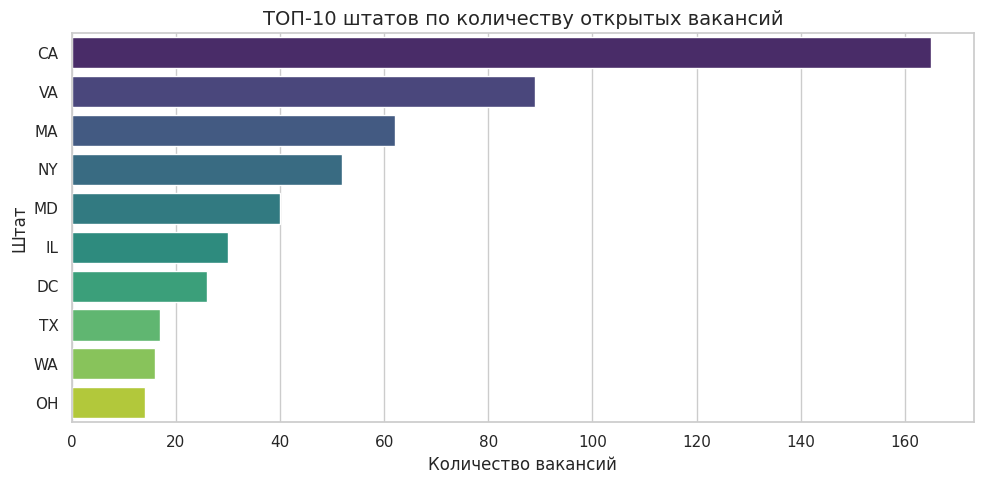

/tmp/ipykernel_2704/697958971.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted_df, x='Skill', y='avg_salary', palette='Set2')


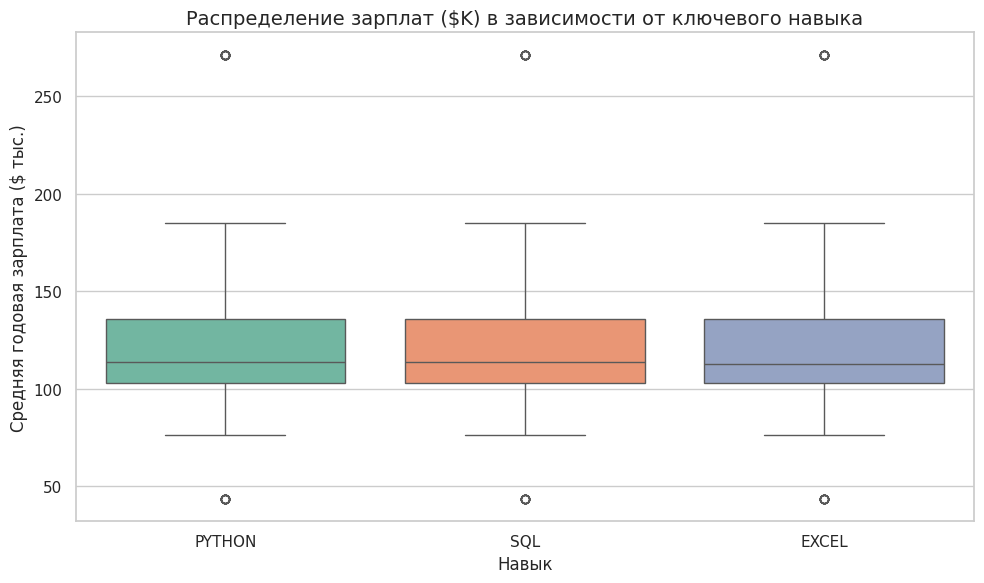

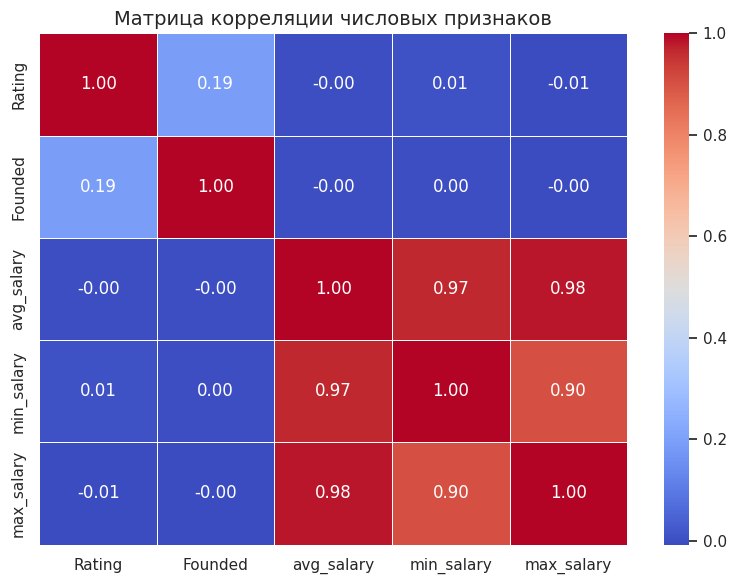

In [40]:
# Настраиваем красивый стиль графиков
sns.set_theme(style="whitegrid")

# ГРАФИК 1: ТОП-10 штатов по количеству вакансий-
plt.figure(figsize=(10, 5))
state_counts = df_clean['State'].value_counts().head(10)
sns.barplot(x=state_counts.values, y=state_counts.index, palette='viridis')
plt.title('ТОП-10 штатов по количеству открытых вакансий', fontsize=14)
plt.xlabel('Количество вакансий')
plt.ylabel('Штат')
plt.tight_layout()
plt.show()

# ГРАФИК 2: Сравнение распределения зарплат для Python, SQL и Excel

# Пересоберем данные для удобного построения Boxplot
melted_df = pd.melt(df_clean, id_vars=['avg_salary'], value_vars=['python_job', 'sql_job', 'excel_job'],
                    var_name='Skill', value_name='Required')
# Оставим только те строки, где навык действительно требуется (Required == 1)
melted_df = melted_df[melted_df['Required'] == 1]
melted_df['Skill'] = melted_df['Skill'].str.replace('_job', '').str.upper()

plt.figure(figsize=(10, 6))
sns.boxplot(data=melted_df, x='Skill', y='avg_salary', palette='Set2')
plt.title('Распределение зарплат ($K) в зависимости от ключевого навыка', fontsize=14)
plt.xlabel('Навык')
plt.ylabel('Средняя годовая зарплата ($ тыс.)')
plt.tight_layout()
plt.show()

# ГРАФИК 3: Тепловая карта корреляции (Heatmap)
plt.figure(figsize=(8, 6))
# Выбираем только ключевые числовые показатели
num_cols = ['Rating', 'Founded', 'avg_salary', 'min_salary', 'max_salary']
corr_matrix = df_clean[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляции числовых признаков', fontsize=14)
plt.tight_layout()
plt.show()